Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.
***

# Введение

В этом домашнем задании мы пройдемся по трем основным типам задач машинного обучения, которые обсуждали на паре:
* **регрессия** (предсказание числа);
* **классификация** (предсказание класса);
* **кластеризация** (поиск скрытых структур в данных).

Подробно про типы задач МО вообще и модели почитать [тут](https://scikit-learn.org/stable/user_guide.html?spm=a2ty_o01.29997173.0.0.3ef45171As9d36).

_Ноутбук представляет из себя работу над **тремя видами задач** и **итоговый отчет**_

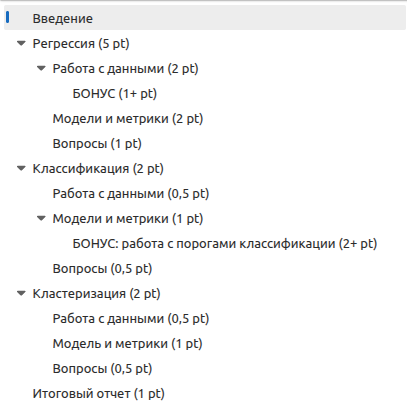

Для каждой задачи нужно поработать с данными, обучить модели и поработать с метриками, ответить на вопросы. Все задания будут подробно сформулированы в соответствующих пунктах.

> **Наша цель — не научиться хорошо предсказывать, а понять, как данные влияют на предсказание и как с ними работать!**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from typing import List, Union, Dict
from tqdm.auto import tqdm
from IPython.display import clear_output

# Регрессия (5 pt)

В задачах регрессии цель — предсказать **непрерывную числовую переменную** (например, цену).  

В этом задании мы будем использовать для предсказания и сравнения две модели: `SGDRegressor` (линейная регрессия, обучающаяся через градиентный спуск) и `RandomForestRegressor`. Обе они легко импортятся, мы будем их просто использовать, не будем погружаться в детали. Однако если вы хотите **поэксперементировать с параметрами**, то вы можете это сделать, но не забудьте **сделать то, что прошу в задании**.

Также в этом задании мы поработаем с _двумя типами кодирования категориальных признаков_ и с _тремя метриками_.

## Работа с данными (2 pt)

Для задачи регрессии возьмем датасет `diamonds`, с которым вы уже знакомы. 

In [2]:
diamonds = sns.load_dataset('diamonds')
diamonds.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


In [3]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


Для начала разделим наши данные на обучающую и тестовую выборки с помощью `train_test_split`: будем использовать **один сид** для сравнения и воспроизводимости (не меняйте его).

In [4]:
X = diamonds.drop('price', axis=1)
y = diamonds['price']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train_raw.shape, X_test_raw.shape)

(43152, 9) (10788, 9)


Теперь будем работать только с обучающим набором, как будто про тест мы ничего не знаем.

**ВАЖНО!**  
Все трансформы и **статистики мы считаем только по трэйну, а к тесту их применяем с теми же параметрами**. Нужно понимать, что про тест мы ничего не знаем, а значит для нас это неизвестный набор данных по подобию трэйна, то есть мы на нем никакие статистики не посчитаем!

Давайте посмотрим, как **распределена целевая переменная**.

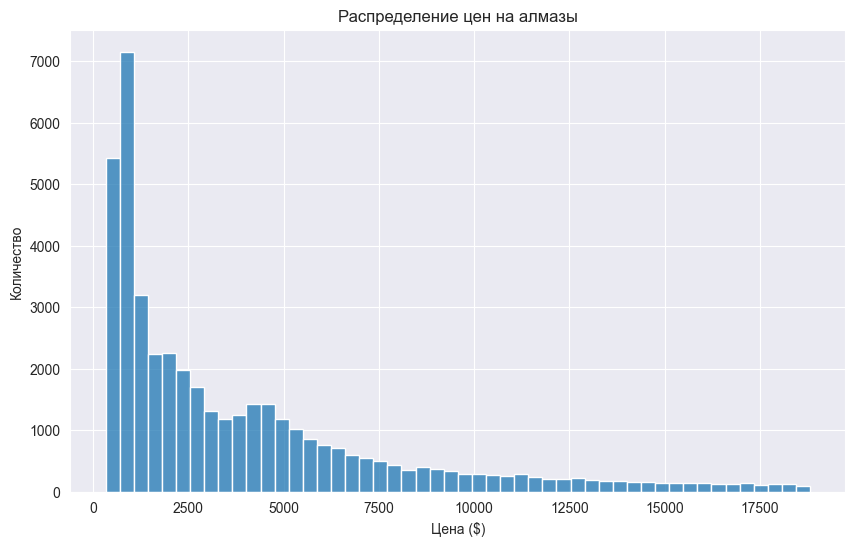

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=y_train, bins=50)
plt.title('Распределение цен на алмазы')
plt.xlabel('Цена ($)')
plt.ylabel('Количество')
plt.show()

Отдельно изучим **категориальные данные**

In [6]:
categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:
    print(X_train_raw[col].value_counts(), "\n")

cut
Ideal        17259
Premium      11016
Very Good     9700
Good          3902
Fair          1275
Name: count, dtype: int64 

color
G    9015
E    7863
F    7644
H    6707
D    5413
I    4274
J    2236
Name: count, dtype: int64 

clarity
SI1     10520
VS2      9793
SI2      7306
VS1      6530
VVS2     4044
VVS1     2944
IF       1430
I1        585
Name: count, dtype: int64 



Какие признаки являются **ординальными** (имеют порядок), а какие **номинальными** (без порядка)?  

**ОТВЕТ:** `Color`, очевидно, - номинальный, `cut` и `clarity` - ординальные, чем выше `Cut` и `Clarity`, тем больше стоимость алмаза, в `EDA` я это проверял

Почистите обучающие данные, если это требуется. Если нет, то напишите, почему вы решили этого не делать.  
(Вы можете сделать то же самое, что делали в третьей домашке)

Окей, просто скопирую код из третьей домашки сюда. 

In [7]:
diamonds = diamonds.drop_duplicates()
diamonds = diamonds[(diamonds.x != 0) & (diamonds.y != 0) & (diamonds.z != 0)]

diamonds['carat_est'] = ((diamonds['x'] + diamonds['y']) / 2) ** 2 * diamonds['z'] * 0.0061
diamonds['carat_diff'] = abs(diamonds['carat'] - diamonds['carat_est']) / diamonds['carat_est']
diamonds_sorted = diamonds.sort_values('carat_diff', ascending=False)

# Удаляем записи с ошибкой > 0.5 (50%)
diamonds = diamonds[diamonds['carat_diff'] <= 0.5].copy()

# Дополнительно можно проверить соотношение x и y
diamonds['xy_ratio'] = diamonds[['x', 'y']].max(axis=1) / diamonds[['x', 'y']].min(axis=1)
# Оставляем только те, где отношение меньше 1.2 (т.е. x и y примерно равны)
diamonds = diamonds[diamonds['xy_ratio'] <= 1.2].copy()

diamonds = diamonds[(diamonds['depth'] >= 50) & (diamonds['depth'] <= 70) &
                    (diamonds['table'] >= 40) & (diamonds['table'] <= 80)].copy()

diamonds = diamonds.drop(columns=['xy_ratio', 'carat_diff', 'carat_est'])

***
Теперь перейдем к подготовке данных для наших моделей. Мы знаем, что линейная регрессия работает только с числами (как вообще говоря многие модели), поэтому нам нужно преобразовать наши **категориальные данные в числа**.

Делают это **двумя базовыми способами**:
* **One-Hot Encoding** — создание отдельного бинарного столбца для каждой категории (1 если равно, 0 иначе).
  - Не создает ложного порядка между категориями.
  - Увеличивает размерность данных.
* **Label Encoding** — присваиваение каждой категории числа.
  - Не увеличивает размерность.
  - Создает ложный порядок.
    
Вот [тут](https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-vs-label-encoding/) кратко про то, как и когда что делать.

Можно делать реализацию этого самостоятельно (как мы и сделаем тут), а можно использовать реализованные методы `OneHotEncoder` и `OrdinalEncoder` из `sklearn.preprocessing`.

**Все ассерты проверяют базовую логику, а не качество реализации!!!**

In [8]:
# ЗАДАНИЕ: реализуйте класс для one-hot encoding
#          метод fit должен на вход принимать датасет, названия столбцов и запоминать состояние
#          метод transform должен принимать датасет и иземнять его (делать экнодинг)

class OwnOneHotEncoding:
    def __init__(self) -> None:
        self.input_columns_ = [] # исходные названия столбцов, чтобы знать что удалять
        self.categories_ = {} # для хранения значений
        

    def fit(self, df: pd.DataFrame, categorical_columns: List[str]) -> None:
        self.input_columns_ = []
        self.categories_ = {}
        for column in categorical_columns:
            if column not in df.columns:
                raise ValueError(f"Колонки '{column}' нет в датафрейме")
            self.input_columns_.append(column)
            # Получаем уникальные значения, игнорируя NaN (мало ли не предобработали нормально)
            unique_vals = df[column].dropna().unique().tolist()
            self.categories_[column] = unique_vals
            

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        encoded_df = df.copy()
        for column in self.input_columns_:
            if column not in encoded_df.columns:
                raise ValueError(f"Колонки '{column}' нет в датафрейме")
            for category in self.categories_[column]:
                new_col_name = f"{column}_{category}"
                encoded_df[new_col_name] = (encoded_df[column] == category).astype(int)
            encoded_df.drop(columns=[column], inplace=True)
        return encoded_df

In [9]:
data_ex_train = pd.DataFrame({
    'color': ['red', 'green', 'blue', 'red', 'green'],
    'size': ['S', 'M', 'L', 'M', 'S'],
    'price': [10, 20, 30, 15, 25]
})

ohe = OwnOneHotEncoding()
ohe.fit(data_ex_train, ['color', 'size'])
encoded_data_ex_train = ohe.transform(data_ex_train)

print(encoded_data_ex_train)
assert encoded_data_ex_train.shape[1] == 7, "Нужно заменить категориальные столбцы на несколько новых"

data_ex_test = pd.DataFrame({
    'color': ['red', 'yellow'],
    'size': ['M', 'XL'],
    'price': [12, 18]
})

encoded_data_ex_test = ohe.transform(data_ex_test)

assert (encoded_data_ex_test.columns == encoded_data_ex_train.columns).all(), "Признаки должны быть такие же, как и в обучающей выборке"

   price  color_red  color_green  color_blue  size_S  size_M  size_L
0     10          1            0           0       1       0       0
1     20          0            1           0       0       1       0
2     30          0            0           1       0       0       1
3     15          1            0           0       0       1       0
4     25          0            1           0       1       0       0


Супер, так же реализуем и `OrdinalEncoding`. Важно, что мы должны уметь **обрабатывать такие значения в тесте, которые не встречались в обучающей выборке**.

In [10]:
# ЗАДАНИЕ: реализуйте класс для label encoding
#          методы fit и transform должны работать аналогично
#          метод inverse_transform должен возвращать датасет с изначальными значениями

class OwnOrdinalEncoding:
    def __init__(self):
        self.input_columns_ = [] # для хранения названия столбцов
        self.categories_ = {} # для хранения значений
        self.mappings_ = {} # для отображений
        self.reverse_mappings_ = {}

    def fit(self, df: pd.DataFrame, categorical_columns: List[str]) -> None:
        self.input_columns_ = []
        self.categories_ = {}

        for column in categorical_columns:
            if column not in df.columns:
                raise ValueError(f"Колонки '{column}' нет в датафрейме")

            self.input_columns_.append(column)

            unique_vals = df[column].dropna().unique().tolist()
            self.categories_[column] = unique_vals
            
            mapping = {category: idx for idx, category in enumerate(unique_vals)}
            self.mappings_[column] = mapping
            self.reverse_mappings_[column] = {idx: category for category, idx in mapping.items()}

            

    def transform(self, df: pd.DataFrame, handle_unknown: str = 'ignore') -> pd.DataFrame:
        encoded_df = df.copy()
        for column in self.input_columns_:
            if column not in encoded_df.columns:
                raise ValueError(f"Колонки '{column}' нет в датафрейме")

            mapping = self.mappings_[column]

            def encode_value(x):
                if x in mapping:
                    return mapping[x]
                if handle_unknown == 'ignore':
                    return -1
                else:
                    raise ValueError(f"Нет категории '{x}' в колонке '{column}'")

            encoded_df[column] = encoded_df[column].apply(encode_value)

        return encoded_df
    
    def inverse_transform(self, df: pd.DataFrame) -> None:
        decoded_df = df.copy()
        for column in self.input_columns_:
            if column not in decoded_df.columns:
                continue 
            reverse_mapping = self.reverse_mappings_[column]

            def decode_value(x):
                if x in reverse_mapping:
                    return reverse_mapping[x]
                return x

            decoded_df[column] = decoded_df[column].apply(decode_value)

        return decoded_df

In [11]:
ore = OwnOrdinalEncoding()
ore.fit(data_ex_train, ['color', 'size'])
encoded_data_ex_train = ore.transform(data_ex_train)

print(encoded_data_ex_train)
assert encoded_data_ex_train.shape[1] == 3, "Нужно оставить старые столбцы"

encoded_data_ex_test = ore.transform(data_ex_test)

assert (encoded_data_ex_test.columns == encoded_data_ex_train.columns).all(), "Признаки должны быть такие же, как и в обучающей выборке"

   color  size  price
0      0     0     10
1      1     1     20
2      2     2     30
3      0     1     15
4      1     0     25


Теперь поговорим про еще одну важную вещь — **нормализацию**.  
**Нормализация** — это процесс приведения числовых признаков к единому масштабу.  

**Почему это важно для линейных моделей?**
1. Градиентный спуск работает быстрее
2. Коэффициенты становятся сравнимыми
3. Регуляризация работает корректно

Для этого будем использовать `StandardScaler`, вот тут [документация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

***
Для того, чтобы проверить разные подходы используем `Pipeline`: некоторый контейнер, который поможет нам заранее сформировать набор действий. Для предсказания будем использовать две модели: `SGDRegressor` и `RandomForestRegressor`.

**Сформируем разные пайплайны**: разные комбинации двух моделей и двух обработок, а также нормализации.

In [12]:
# вставьте параметры, если не хотите использовать стандартные
pipeline_ohe_norm_lin = Pipeline(steps=[
    ('encoder', OwnOneHotEncoding()),
    ('scaler', StandardScaler()),
    ('model', SGDRegressor())
])

pipeline_ord_norm_lin = Pipeline(steps=[
    ('encoder', OwnOrdinalEncoding()),
    ('scaler', StandardScaler()),
    ('model', SGDRegressor())
])

pipeline_ord_lin = Pipeline(steps=[
    ('encoder', OwnOrdinalEncoding()),
    ('model', SGDRegressor())
])

pipeline_ord_rf = Pipeline(steps=[
    ('encoder', OwnOrdinalEncoding()),
    ('model', RandomForestRegressor())
])

pipeline_ohe_norm_rf = Pipeline(steps=[
    ('encoder', OwnOneHotEncoding()),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

pipeline_ohe_rf = Pipeline(steps=[
    ('encoder', OwnOneHotEncoding()),
    ('model', RandomForestRegressor())
])

### БОНУС (1+ pt)
Сделайте **комбинированный пайплайн** для нужных столбцов (разная обработка разных столбцов) и для него пройдите следующие два пункта. Проверьте его на **обеих моделях**. Отдельно выделяйте результаты, чтобы я могла понять, что относится к бонусу.

In [13]:
category_cols = ['color']
ordinal_cols = ['cut','clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), category_cols),
        ('ordinal', OrdinalEncoder(categories=[
            ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], 
            ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
        ]), ordinal_cols),
        ('scale', StandardScaler(), numeric_cols)
    ],
)

my_pipeline_sgd = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(random_state=42))
])

my_pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

## Модели и метрики (2 pt)

Ну чтож, можем приступать к обучению. Ну почти  

Перед этим определим **метрики**, с помощью которых будем мерить наши результаты:
* **MAE (Mean Absolute Error)** — средняя абсолютная ошибка. Показывает, на сколько пунктов в среднем ошибается модель в предсказаниях.
* **RMSE (Root Mean Squared Error)** — корень из средней квадратичной ошибки. Показывает «типичную» величину ошибки, но сильнее штрафует за большие отклонения.
* **$R^2$ (Coefficient of Determination)** — коэффициент детерминации. Показывает, какую долю дисперсии целевой переменной объясняет модель по сравнению с простым средним.

Их объяснение в лекции или в интернетах. Конечно, мы можем взять реализации `mean_absolute_error`, `mean_squared_error` и `r2_score` из `sklearn.metrics`, но сперва реализуем сами.

In [14]:
# ЗАДАНИЕ: реализуйте собственные функции метрик
ArrayLike = Union[np.ndarray, pd.Series, List[float]]

def own_mean_absolute_error(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def own_mean_squared_error(y_true: ArrayLike, y_pred: ArrayLike, root: bool = False) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mse = np.mean((y_true - y_pred) ** 2)
    return np.sqrt(mse) if root else mse

def own_r2_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

In [15]:
y_true_test = [1, 1, 4, 3, 2]
y_pred_test = [1, 2, 1, 4, 2]

assert np.isclose(own_mean_absolute_error(y_true_test, y_pred_test), mean_absolute_error(y_true_test, y_pred_test))
assert np.isclose(own_mean_squared_error(y_true_test, y_pred_test), mean_squared_error(y_true_test, y_pred_test))
assert np.isclose(own_mean_squared_error(y_true_test, y_pred_test, root=True), root_mean_squared_error(y_true_test, y_pred_test))
assert np.isclose(own_r2_score(y_true_test, y_pred_test), r2_score(y_true_test, y_pred_test))

Теперь все точно готово, приступим к обучению. Большая часть кода уже написана, вам нужно только его дополнить

In [16]:
pipelines = [pipeline_ohe_norm_lin, pipeline_ord_norm_lin, pipeline_ord_lin, pipeline_ord_rf, pipeline_ohe_norm_rf, pipeline_ohe_rf, my_pipeline_sgd, my_pipeline_rf]
pipeline_names = ['pipeline_ohe_norm_lin', 'pipeline_ord_norm_lin', 'pipeline_ord_lin',
                  'pipeline_ord_rf', 'pipeline_ohe_norm_rf', 'pipeline_ohe_rf', 'my_pipeline_sgd', 'my_pipeline_rf']
categorical_features = ['cut', 'color', 'clarity']

metrics = {}

# Разделение на признаки и целевую переменную
X = diamonds.drop('price', axis=1)
y = diamonds['price']

# Разделение на обучающую и тестовую выборки

for pipeline, name in tqdm(zip(pipelines, pipeline_names)):
    # поскольку кастомные пайплайны через трансформер, придётся модифицировать цикл
    X_train = X_train_raw.copy() 
    X_test = X_test_raw.copy()

    if 'encoder' in pipeline.named_steps:
        pipeline.named_steps['encoder'].fit(X_train, categorical_features)
        X_train = pipeline.named_steps['encoder'].transform(X_train)
        X_test = pipeline.named_steps['encoder'].transform(X_test)

        if 'scaler' in pipeline.named_steps:
            pipeline.named_steps['scaler'].fit(X_train)
            X_train = pipeline.named_steps['scaler'].transform(X_train)
            X_test = pipeline.named_steps['scaler'].transform(X_test)

        pipeline.named_steps['model'].fit(X_train, y_train)
        y_pred = pipeline.named_steps['model'].predict(X_test)
    else:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

    metrics[name] = {}
    metrics[name]['mae'] = own_mean_absolute_error(y_test, y_pred)
    metrics[name]['rmse'] = own_mean_squared_error(y_test, y_pred, root=True)
    metrics[name]['r2'] = own_r2_score(y_test, y_pred)

0it [00:00, ?it/s]

In [17]:
results_df = pd.DataFrame(metrics).T
results_df.index.name = 'model'
results_df = results_df.reset_index()

results_df['mae'] = results_df['mae'].round(2)
results_df['rmse'] = results_df['rmse'].round(2)
results_df['r2'] = results_df['r2'].round(4)
results_df

,model,mae,rmse,r2
0,pipeline_ohe_norm_lin,742.63,1136.24,9.188000e-01
1,pipeline_ord_norm_lin,886.98,1463.31,8.653000e-01
2,pipeline_ord_lin,18662324.59,24654834.40,-3.823789e+07
3,pipeline_ord_rf,273.24,553.27,9.807000e-01
4,pipeline_ohe_norm_rf,271.23,552.30,9.808000e-01
5,pipeline_ohe_rf,272.10,554.00,9.807000e-01
6,my_pipeline_sgd,776.39,1207.98,9.082000e-01
7,my_pipeline_rf,267.69,545.09,9.813000e-01


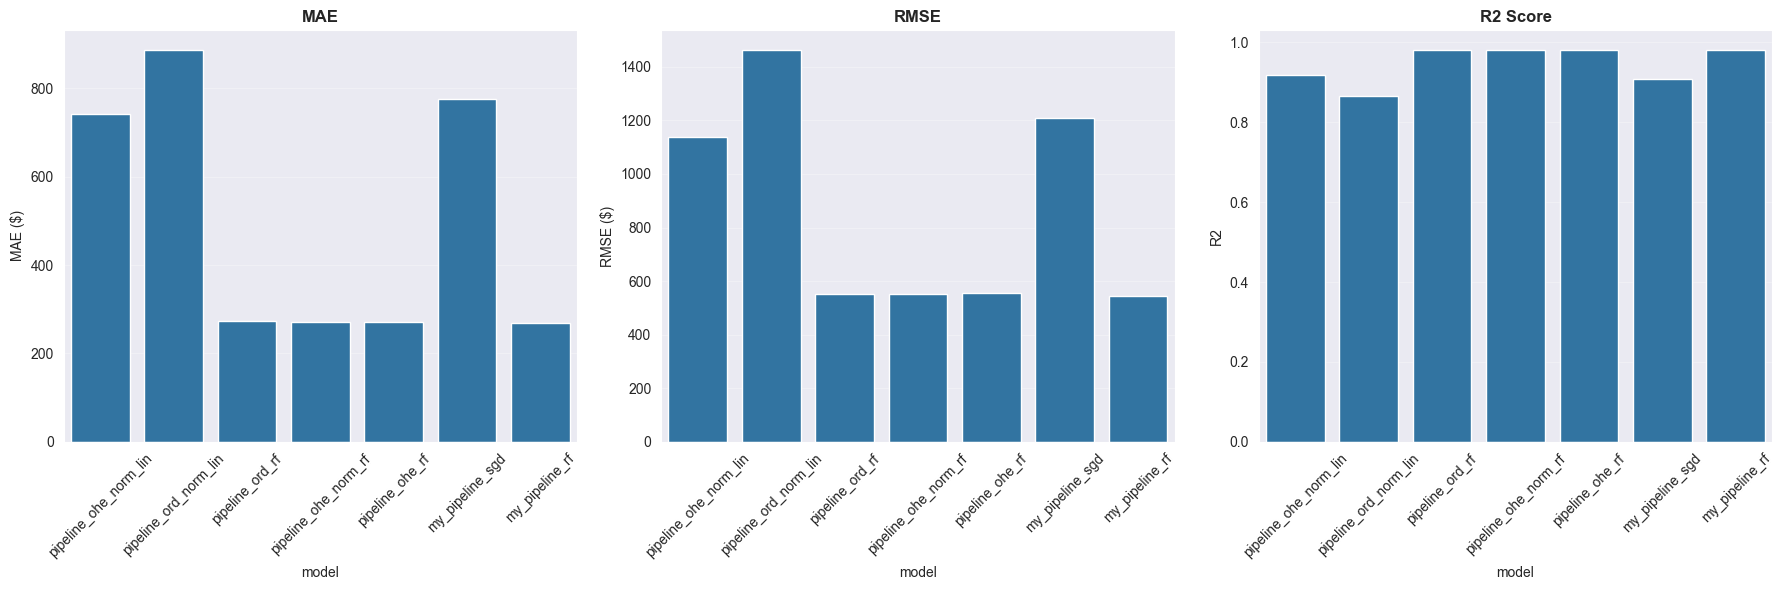

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# из-за огромных ошибок в pipeline_ord_lin графики неинформативные, поэтому уберу его, чтобы сравнить остальные
results_df = results_df[results_df['model'] != 'pipeline_ord_lin']

sns.barplot(data=results_df, x='model', y='mae', ax=axes[0])
axes[0].set_title('MAE', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('MAE ($)')
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='rmse', ax=axes[1])
axes[1].set_title('RMSE', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('RMSE ($)')
axes[1].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='r2', ax=axes[2])
axes[2].set_title('R2 Score', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('R2')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Выводы к бонусу:

- Почему для SGD мой пайплайн дал результат между OHE и Ord?
    Линейная модель работает с признаками как с числами.

    OHE создаёт отдельный бинарный признак для каждого уровня. Модель может назначить каждому уровню свой независимый вес, что не навязывает ложного порядка.
    
    При Ordinal модель вынуждена считать, что разница между 1 и 2 такая же, как между 2 и 3. Если на самом деле влияние на целевую переменную нелинейно: например, переход от Fair к Good даёт +100, а от Good к Very Good +50, как у нас и есть, то модель будет ошибаться.
    
    У нас cut и clarity имеют порядок, но не равномерное влияние. Поэтому pipeline_ohe_norm_lin показал лучший результат среди всех пайплайнов, а ord - худший.
    
- Почему для RF мой пайплайн оказался чуть лучше остальных?
    Тут мне сложнее объяснить, с чем это связано, не совсем понимаю. Читал, что если всё кодировать OHE, то деревья могут переобучиться. Может, тут в этом дело - равномерное использование OHE и Ordinal... 

Кажется, все RF лучше всех SGD, потому что у нас есть нелинейные зависимости между признаками, и эта модель просто лучше. Плюс, насколько я знаю, RF в силу своей структуры, логики, в целом лучше работает с данными, в которых есть категориальные признаки



## Вопросы (1 pt)

1. В чём разница между `One-Hot Encoding` и `Ordinal (Label) Encoding`? Когда какой метод следует использовать?
2. Почему `Ordinal Encoding` опасен для линейной регрессии? Приведите конкретный пример.
3. Что произойдёт, если в тестовых данных появится категория, которой не было в обучающих? Как это обрабатывать?
4. Почему `fit()` вызывается только на `train` данных, а `transform()` — и на `train`, и на `test`? Что будет, если сделать `fit()` на всём датасете?
5. Как на предсказание влияет нормализация?
6. Как интерпретировать полученные метрики?
7. Какую метрику вы бы выбрали как основную для бизнес-задачи предсказания цен на алмазы? Почему?

**ОТВЕТЫ:** _(ожидается 7 емких ответов)_

1) Разница в том, что Ordinal задаёт порядок, то есть подразумевается, что у категорий есть порядок. OHE создаёт отдельный бинарный столбец для каждой категории, без порядка. При использовании Ordinal размерность не растёт, при OHE (без использования other), растёт на N-1, где N - количество категорий. Когда что использовать: Ordinal в случае, если есть реальный порядок или страшно потерять в размерности, OHE - когда порядка нет и допустимо так увеличить размерность. 
2) Линейная модель просто домножает столбцы на коэффициенты, то есть воспринимает числа буквально. Если закодируем cut, то модель решит, что Ideal в 4 раза лучше Fair и будет предсказывать цену пропорционально. В общем, модель обучится ложной зависимости...
3) OwnOrdinalEncoding вернёт -1, OwnOneHotEncoding просто не создаст нового столбца. Неизвестная категория получит 0 во всех OHE-столбцах.
4) fit() изучает статистику данных (уникальные категории, среднее, std). Если сделать fit() на всём датасете, модель косвенно увидит тестовые данные до обучения. Будет утечка данных
5) SGD пошагово подбирает коэффициенты. Если признаки в разных масштабах, то градиент тянется сильнее в сторону признаков с большим масштабом, обучение получается нестабильным или вовсе расходится. Деревьям, в отличие от линеек, нормализация не так нужна, потому что они определяют пороги, когда строят дерево решений. Для них масштаб не важен.
6) MAE - средняя ошибка в долларах. К примеру, если MAE=400, то в среднем ошибаемся на 400 долларов.
    RMSE - почти то же, но штрафует сильнее за большие ошибки (из-за квадрата). Если RMSE сильно больше MAE, значит есть "выбросы" в ошибках - место, где мы ошиблись гораздо сильнее обычного.
    R2 — доля объяснённой дисперсии. К примеру, если R2=0.98, модель объясняет 98% разброса цен. Если R2<0, то использовать модель хуже, чем просто предсказывать средним
7) Для цен на алмазы я бы использовал MAPE.
    Почему не RMSE или MAE: для алмаза стоимостью 50000 ошибка на 100 незначительна, для алмаза 1000 - много. Нам нужно относительное значение, а не средняя ошибка.
    Почему не R2: бизнес не понимает "долю дисперсии", это вообще не интуитивная метрика для интерпретации. 
    С MAPE круто и просто: MAPE=5% -> в среднем ошибаемся на 5% от цены алмаза. Это одинаково понятно для дешёвых и дорогих.





# Классификация (2 pt)

Для этого задания будем использовать датасет `Telco-Customer-Churn` вот [тут](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) можно почитать описание столбцов. Наша задача — предсказать столбец `Churn`, то есть ушел пользователь, или остался.  

В этом пункте мы будем использовать три модели: `LogisticRegression`, `RandomForestClassifier` и `CatBoostClassifier`. Если хотите, то можете подбирать параметры, но можно сравнивать и с параметрами «из коробки».

## Работа с данными (0,5 pt)

In [19]:
TCC = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv').dropna()
# обработка, чтобы была одинаковая у всех
TCC = TCC.drop('customerID', axis=1)
TCC['Churn'] = (TCC['Churn'] == 'Yes').astype(int)
TCC['TotalCharges'] = pd.to_numeric(TCC['TotalCharges'], errors='coerce')
TCC = TCC.dropna()
print(TCC.shape)
TCC.head(3)

(7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [20]:
TCC.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [21]:
X = TCC.drop('Churn', axis=1)
y = TCC['Churn']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train_raw.shape, X_test_raw.shape)

(5625, 19) (1407, 19)


**ЗАДАНИЕ:**  
Проанализируйте столбцы и подготовьте **пайплайн обучения**. Вы можете как использовать свои реализации методов, так и реализации из библиотеки. ВАЖНО аргументировать, почему вы выбрали такую обработку. **ПОЭКСПЕРЕМЕНТИРУЙТЕ С РАЗНЫМИ ПАЙПЛАЙНАМИ**

In [22]:
# Я оставила шаблон того, как делала я, вы можете его менять

#Тут я всё ещё не поэкспериментировал с пайплайнами, делаю это позже
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train_raw.select_dtypes(include='str').columns]

# для регрессии
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # масштабируем числовые
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # one-hot для категорий
    ])

# для ансамблей
preprocessor_ens = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features) # ordinal для категорий
    ])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression())
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_ens),
    ('model', RandomForestClassifier())
])

pipeline_cb = Pipeline(steps=[
    ('preprocessor', preprocessor_ens),
    ('model', CatBoostClassifier())
])

**ОБЪЯСНЕНИЕ:**

1) Для логистической регрессии:
    - Числовые признаки масштабируются, что необходимо для регрессии
    - Категориальные кодируются one‑hot, чтобы не вносить ложный порядок и соотношения.
    
2) Для деревьев:
    - Числовые признаки остаются без изменений (масштабирование деревьям и бустингам не нужно).
    - Для категорий используются ordinal, потому что это компактнее, и деревьям с Ordinal работать норм (у них логика работы другая)



## Модели и метрики (1 pt)

Если вы хорошо проанализировали данные, то заметили, что у нас явный **дисбалланс классов** (одного класса сильно меньше, чем другого). Поэтому просто точность для нас не подойдет. 

In [23]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

Почему **`accuracy` бесполезна при дисбалансе**:
Если 73% клиентов не уходят, модель, которая всегда предсказывает "No", получит `accuracy` 73%, но будет полностью бесполезна для бизнеса.

**Confusion Matrix (Матрица ошибок)**  
Все правильные метрики строятся на основе `Confusion Matrix`. Это таблица 2x2, которая показывает, какие ошибки делает модель:

|   | Предсказано 0 | Предсказано 1 |
| :-| :------------ | :------------ |
| **Фактически 0** | `True Negative` | `False Positive` |
| **Фактически 1**  | `False Negative` | `True positive` |

На этом основываются другие метрики для классификации помимо `accuracy`:
* **precision** (`TP / (TP + FP)`) — когда ложные срабатывания дороги,
* **recall** (`TP / (TP + FN)`) — когда пропуск объекта стоит дорого,
* **F1-Score** (`2 * (Prec * Rec) / (Prec + Rec)`) — Баланс между precision и recall.

Подробнее читать [про метрики тут](https://habr.com/ru/companies/ods/articles/328372/).

In [24]:
# ЗАДАНИЕ: реализуйте собственные функции метрик
ArrayLike = Union[np.ndarray, pd.Series, List[float]]

def own_confusion_matrix(y_true: ArrayLike, y_pred: ArrayLike) -> Dict[str, int]:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Элементы confusion matrix
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    return {'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}

def own_precision_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    
    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

def own_recall_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

def own_f1_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    precision = own_precision_score(y_true, y_pred)
    recall = own_recall_score(y_true, y_pred)
    
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

def own_accuracy_score(y_true: ArrayLike, y_pred: ArrayLike) -> float:
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    
    if total == 0:
        raise ValueError("Нет данных (размер y_true равен 0)")
    return correct / total

In [25]:
y_true_test = [1, 1, 0, 0, 0]
y_pred_test = [1, 0, 1, 0, 1]

assert np.isclose(own_precision_score(y_true_test, y_pred_test), precision_score(y_true_test, y_pred_test))
assert np.isclose(own_recall_score(y_true_test, y_pred_test), recall_score(y_true_test, y_pred_test))
assert np.isclose(own_f1_score(y_true_test, y_pred_test), f1_score(y_true_test, y_pred_test))
assert np.isclose(own_accuracy_score(y_true_test, y_pred_test), accuracy_score(y_true_test, y_pred_test))

Теперь **обучим** то, что вы сделали

In [26]:
pipelines = [pipeline_cb, pipeline_lr, pipeline_rf]
pipeline_names = ['CatBoost', 'Logistic Regression', 'Random Forest']

metrics = {}

for pipeline, name in tqdm(zip(pipelines, pipeline_names)):
    pipeline.fit(X_train_raw, y_train)

    y_pred = pipeline.predict(X_test_raw)
    y_prob = pipeline.predict_proba(X_test_raw)[:, 1] # если хотите вероятности, а не классы

    metrics[name] = {}
    metrics[name]['precision'] = own_precision_score(y_test, y_pred)
    metrics[name]['recall'] = own_recall_score(y_test, y_pred)
    metrics[name]['f1-score'] = own_f1_score(y_test, y_pred)
    metrics[name]['accuracy'] = own_accuracy_score(y_test, y_pred)

clear_output()

In [27]:
results_df = pd.DataFrame(metrics).T
results_df.index.name = 'model'
results_df = results_df.reset_index()

results_df['precision'] = results_df['precision'].round(2)
results_df['recall'] = results_df['recall'].round(2)
results_df['f1-score'] = results_df['f1-score'].round(4)
results_df['accuracy'] = results_df['accuracy'].round(2)
results_df

,model,precision,recall,f1-score,accuracy
0,CatBoost,0.63,0.50,0.5561,0.79
1,Logistic Regression,0.62,0.52,0.5656,0.79
2,Random Forest,0.64,0.46,0.5319,0.79


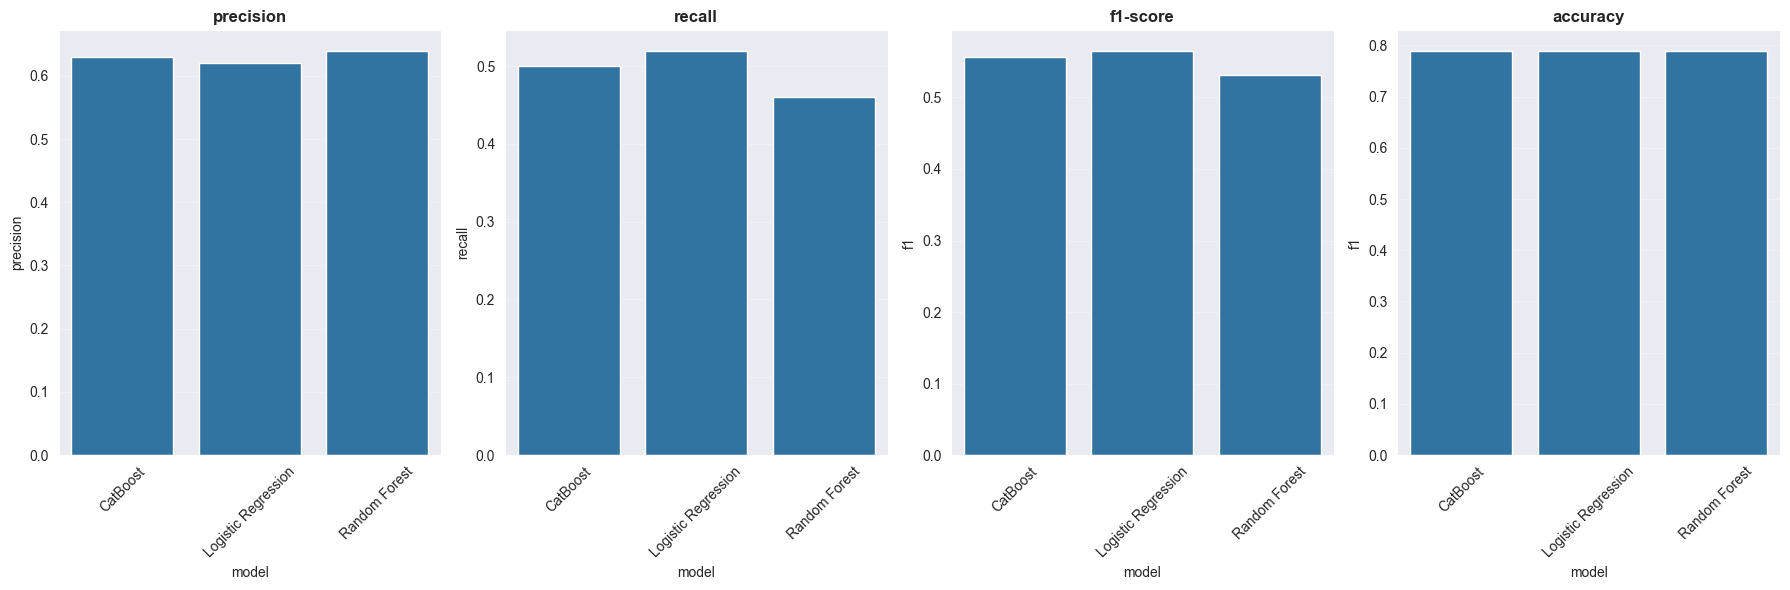

In [28]:
# ЗАДАНИЕ: визуализируйте метрики
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

sns.barplot(data=results_df, x='model', y='precision', ax=axes[0])
axes[0].set_title('precision', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('precision')
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='recall', ax=axes[1])
axes[1].set_title('recall', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('recall')
axes[1].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='f1-score', ax=axes[2])
axes[2].set_title('f1-score', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('f1')
axes[2].grid(axis='y', alpha=0.3)

sns.barplot(data=results_df, x='model', y='accuracy', ax=axes[3])
axes[3].set_title('accuracy', fontsize=12, fontweight='bold')
axes[3].tick_params(axis='x', rotation=45)
axes[3].set_ylabel('f1')
axes[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### БОНУС: работа с порогами классификации (2+ pt)

По умолчанию **порог классификации** стоит 0,5. Поэксперементируйте с этим порогом, как это **повлияет на метрики**?  
В этом пункте напишите код экспериментов и получите метрики, а также напишите отдельный **вывод** для бонуса.

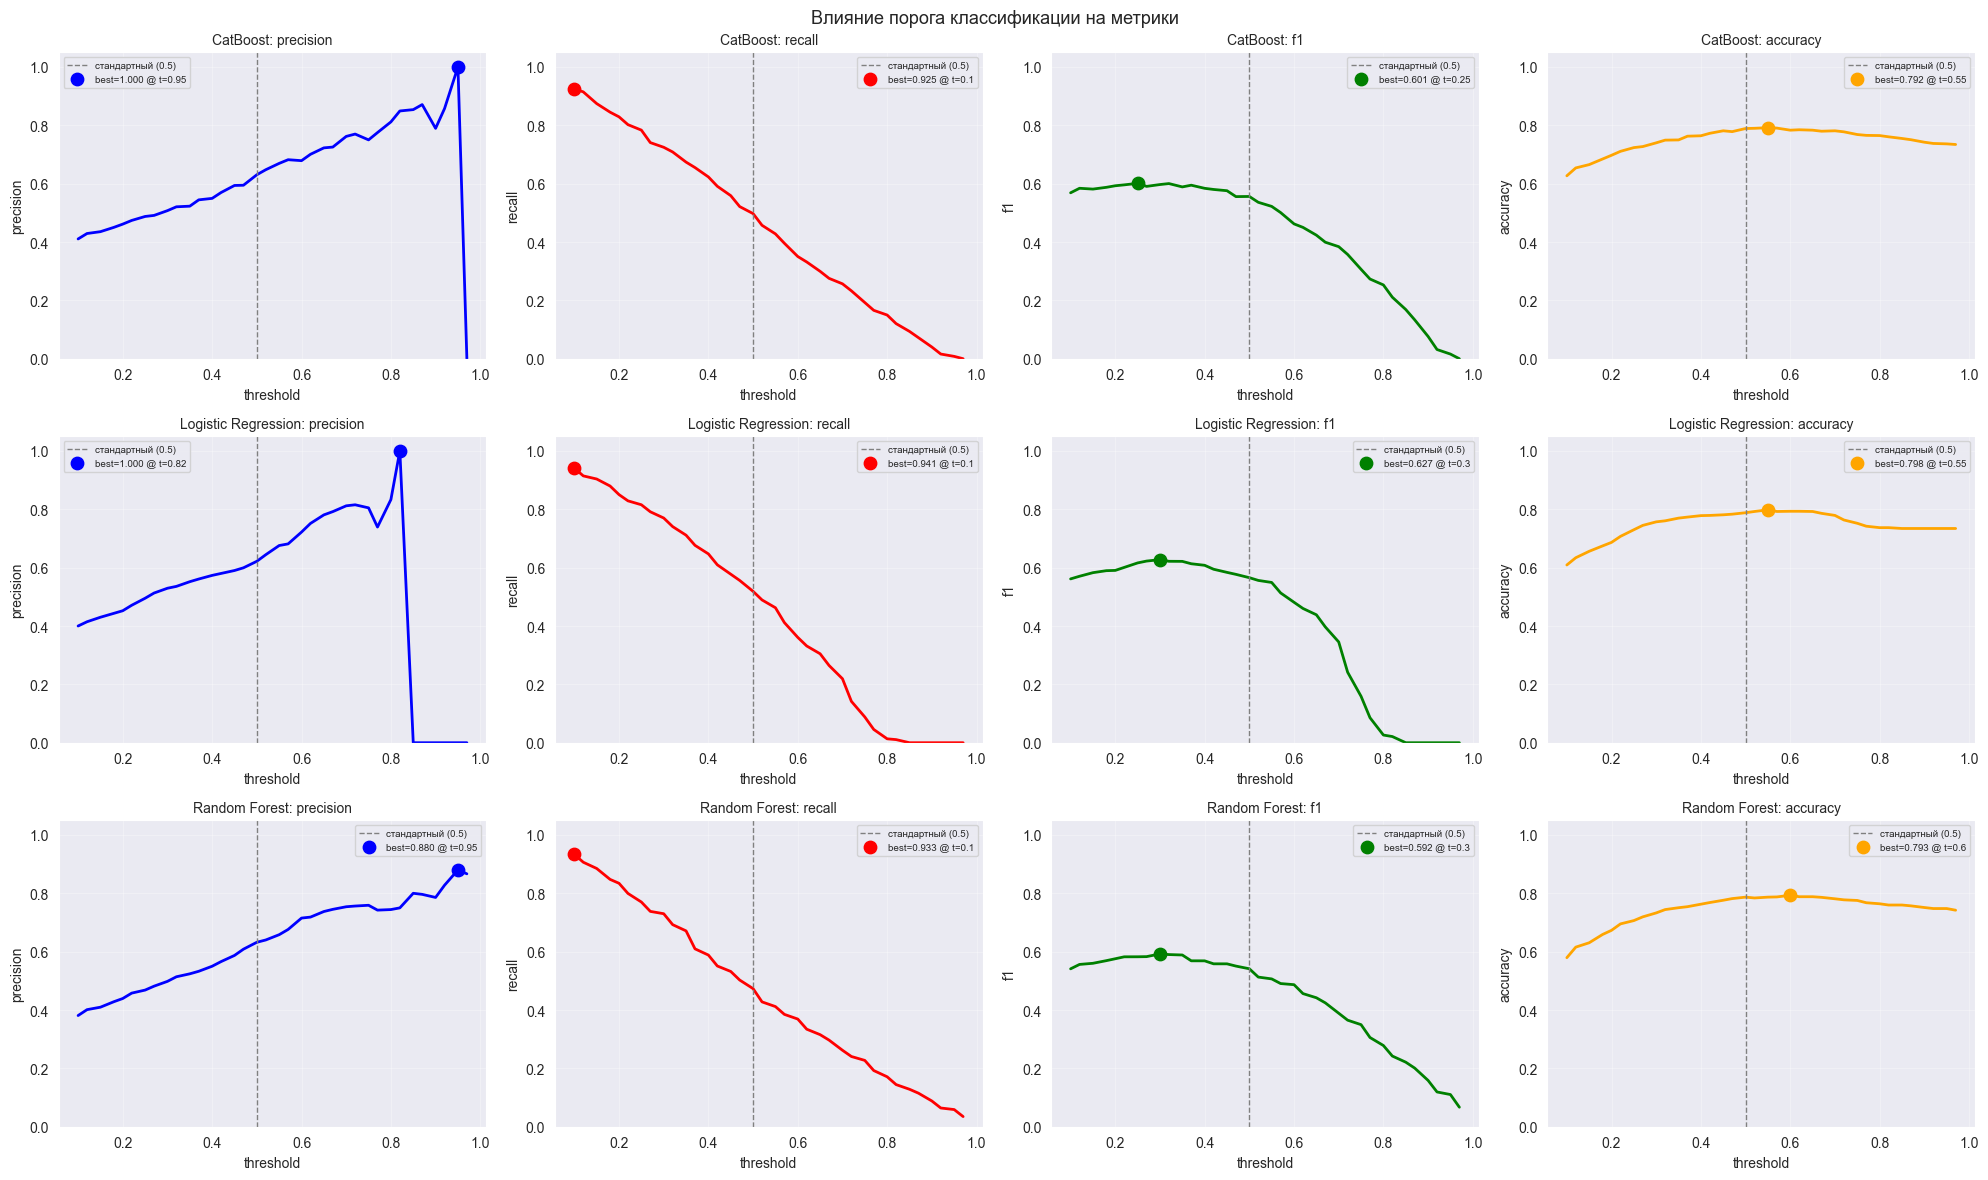

,model,threshold,precision,recall,f1,accuracy
6,CatBoost,0.25,0.4875,0.7834,0.6010,0.7235
8,Logistic Regression,0.30,0.5294,0.7701,0.6275,0.7569
8,Random Forest,0.30,0.4982,0.7299,0.5922,0.7328


In [29]:
thresholds = np.arange(0.1, 1.0, 0.025)

threshold_results = {}

for pipeline, name in zip(pipelines, pipeline_names):
    y_prob = pipeline.predict_proba(X_test_raw)[:, 1]
    
    records = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        records.append({
            'threshold': round(t, 2),
            'precision': own_precision_score(y_test, y_pred_t),
            'recall':    own_recall_score(y_test, y_pred_t),
            'f1':        own_f1_score(y_test, y_pred_t),
            'accuracy':  own_accuracy_score(y_test, y_pred_t),
        })
    threshold_results[name] = pd.DataFrame(records)

fig, axes = plt.subplots(len(pipelines), 4, figsize=(20, 4 * len(pipelines)))

metrics_to_plot = ['precision', 'recall', 'f1', 'accuracy']
colors = ['blue', 'red', 'green', 'orange']

for row, name in enumerate(pipeline_names):
    df = threshold_results[name]
    for col, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
        ax = axes[row][col]
        ax.plot(df['threshold'], df[metric], color=color, linewidth=2)
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='стандартный (0.5)')
        
        best_idx = df[metric].idxmax()
        best_t   = df.loc[best_idx, 'threshold']
        best_v   = df.loc[best_idx, metric]
        ax.scatter([best_t], [best_v], color=color, s=80, zorder=5,
                   label=f'best={best_v:.3f} @ t={best_t}')
        
        ax.set_title(f'{name}: {metric}', fontsize=10)
        ax.set_xlabel('threshold')
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle('Влияние порога классификации на метрики', fontsize=13)
plt.tight_layout()
plt.show()

summary = []
for name, df in threshold_results.items():
    best_row = df.loc[df['f1'].idxmax()].copy()
    best_row['model'] = name
    summary.append(best_row)

summary_df = pd.DataFrame(summary)[['model', 'threshold', 'precision', 'recall', 'f1', 'accuracy']]
summary_df[['precision','recall','f1','accuracy']] = summary_df[['precision','recall','f1','accuracy']].round(4)
summary_df


#### Вывод:

Порог классификации по умолчанию - не всегда оптимальный выбор.

Что происходит при снижении порога:
- Модель осторожнее, больше клиентов помечается как потенциальный отток.
- Recall растёт: мы реже пропускаем реальных уходящих клиентов (меньше False Negative).
- Precision падает: среди предсказанных оттоков появляется больше ошибочно помеченных (больше False Positive).

Вывод: Стоит использовать, когда цена пропуска оттока высока (например, потеря крупного клиента).



Что происходит при повышении порога:
- Модель строже, в отток попадают только самые очевидные случаи.
- Precision растёт: предсказания точнее, меньше ложных тревог.
- Recall падает: часть реальных уходящих клиентов остаётся незамеченной.

Вывод: Стоит использовать, когда ресурс удержания ограничен и нужно бить точно в цель.

Для большинства моделей на этих данных оптимальный порог оказался ниже 0,5. Думаю, это связано с дисбалансом классов: модели при пороге 0,5 недооценивают меньший класс (как раз отток). При дисбалансе классов стоит снижать порог, ориентируясь на F1 или бизнес-приоритет (что дороже: пропустить отток или ложно сработать).


## Вопросы (0,5 pt)

1. Какая обработка данных дает лучший результат?
2. Какая обработка данных подходит для каждой модели лучше?
3. Как интерпретировать полученные метрики?

Хотел чистый ноутбук, и, кажется, ячейки с экспериментами над пайплайнами лучше зайдут сюда, как отдельное исследование. Будем исследовать разные пайплайны для каждой модели отдельно, чтобы не перегружать ячейки. Начнём с логистической регрессии. Чтобы было с чем сравнивать, я также захотел рассмотреть SGDClassifier - аналог SGDRegressor для задач классификации. Гиперпараметры я тут не подбирал, сравнивал "из коробки".

In [30]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

In [31]:
scaler_std = StandardScaler()
scaler_robust = RobustScaler()
scaler_minmax = MinMaxScaler()

ohe = OneHotEncoder(handle_unknown='ignore')
ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
target_enc = TargetEncoder(target_type='binary') # Поскольку говорим да / нет 


preprocessor_lr_std_ohe = ColumnTransformer([
    ('num', scaler_std, numeric_features),
    ('cat', ohe, categorical_features)
])

preprocessor_lr_robust_ohe = ColumnTransformer([
    ('num', scaler_robust, numeric_features),
    ('cat', ohe, categorical_features)
])

preprocessor_lr_std_target = ColumnTransformer([
    ('num', scaler_std, numeric_features),
    ('cat', target_enc, categorical_features)
])

preprocessor_lr_robust_target = ColumnTransformer([
    ('num', scaler_robust, numeric_features),
    ('cat', target_enc, categorical_features)
])

preprocessor_ens_ord = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', ordinal, categorical_features)
])

# Базовые пайплайны LogisticRegression
pipelines_lr = {
    'LR_std_ohe': Pipeline([('prep', preprocessor_lr_std_ohe), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'LR_robust_ohe': Pipeline([('prep', preprocessor_lr_robust_ohe), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'LR_std_target': Pipeline([('prep', preprocessor_lr_std_target), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'LR_robust_target': Pipeline([('prep', preprocessor_lr_robust_target), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
}

# SGDClassifier – чувствителен к масштабу, поэтому используем масштабирование
pipelines_sgd = {
    'SGD_std_ohe': Pipeline([('prep', preprocessor_lr_std_ohe), ('clf', SGDClassifier(max_iter=1000, random_state=42, loss='log_loss'))]),
    'SGD_robust_ohe': Pipeline([('prep', preprocessor_lr_robust_ohe), ('clf', SGDClassifier(max_iter=1000, random_state=42, loss='log_loss'))]),
    'SGD_std_target': Pipeline([('prep', preprocessor_lr_std_target), ('clf', SGDClassifier(max_iter=1000, random_state=42, loss='log_loss'))]),
    'SGD_robust_target': Pipeline([('prep', preprocessor_lr_robust_target), ('clf', SGDClassifier(max_iter=1000, random_state=42, loss='log_loss'))]),
}

In [32]:
results = {}

print("Логистическая регрессия")
for name, pipe in pipelines_lr.items():
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1')
    results[name] = scores.mean()
    print(f"{name}: среднее f1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\nSGDClassifier")
for name, pipe in pipelines_sgd.items():
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1')
    results[name] = scores.mean()
    print(f"{name}: среднее f1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

Логистическая регрессия
LR_std_ohe: среднее f1 = 0.6062 (+/- 0.0210)
LR_robust_ohe: среднее f1 = 0.6056 (+/- 0.0236)
LR_std_target: среднее f1 = 0.5944 (+/- 0.0226)
LR_robust_target: среднее f1 = 0.5923 (+/- 0.0225)

SGDClassifier
SGD_std_ohe: среднее f1 = 0.5723 (+/- 0.0538)
SGD_robust_ohe: среднее f1 = 0.5705 (+/- 0.0531)
SGD_std_target: среднее f1 = 0.6152 (+/- 0.0212)
SGD_robust_target: среднее f1 = 0.5935 (+/- 0.0307)


Теперь сравним с разными пайплайнами RandomForest и CatBoost.

In [33]:
preprocessor_rf_ord = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', ordinal, categorical_features)
])

preprocessor_rf_ohe = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', ohe, categorical_features)
])

preprocessor_rf_target = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', target_enc, categorical_features)
])

scaler = StandardScaler()
preprocessor_rf_scale_ord = ColumnTransformer([
    ('num', scaler, numeric_features),
    ('cat', ordinal, categorical_features)
])

pipelines_rf = {
    'RF_ord': Pipeline([('prep', preprocessor_rf_ord), 
                        ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    'RF_ohe': Pipeline([('prep', preprocessor_rf_ohe), 
                        ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    'RF_target': Pipeline([('prep', preprocessor_rf_target), 
                           ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    'RF_scale_ord': Pipeline([('prep', preprocessor_rf_scale_ord), 
                              ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])
}

In [34]:
# CatBoost без нативных категорий, только числовые признаки
pipeline_cb_ord = Pipeline([
    ('prep', preprocessor_rf_ord),  # OrdinalEncoder для категорий, числовые passthrough
    ('model', CatBoostClassifier(random_state=42, verbose=False))
])

pipeline_cb_target = Pipeline([
    ('prep', preprocessor_rf_target),  # TargetEncoder для категорий
    ('model', CatBoostClassifier(random_state=42, verbose=False))
])

# Можно добавить вариант с масштабированием числовых и Ordinal для категорий
preprocessor_cb_scale_ord = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
])

pipeline_cb_scale_ord = Pipeline([
    ('prep', preprocessor_cb_scale_ord),
    ('model', CatBoostClassifier(random_state=42, verbose=False))
])

pipelines_cb = {
    'CB_ord': pipeline_cb_ord,
    'CB_target': pipeline_cb_target,
    'CB_scale_ord': pipeline_cb_scale_ord
}

In [35]:

print("Random Forest")
rf_results = {}
for name, pipe in pipelines_rf.items():
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1')
    rf_results[name] = scores.mean()
    print(f"{name}: mean f1 = {scores.mean():.4f} (+/- {scores.std():.4f})")


print("\nCatBoost")
cb_results = {}
for name, pipe in pipelines_cb.items():
    scores = cross_val_score(pipe, X_train_raw, y_train, cv=5, scoring='f1')
    cb_results[name] = scores.mean()
    print(f"{name}: mean f1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

Random Forest
RF_ord: mean f1 = 0.5608 (+/- 0.0230)
RF_ohe: mean f1 = 0.5545 (+/- 0.0106)
RF_target: mean f1 = 0.5730 (+/- 0.0160)
RF_scale_ord: mean f1 = 0.5606 (+/- 0.0237)

CatBoost
CB_ord: mean f1 = 0.5797 (+/- 0.0296)
CB_target: mean f1 = 0.5880 (+/- 0.0258)
CB_scale_ord: mean f1 = 0.5795 (+/- 0.0293)


**ОТВЕТЫ:**

Продублирую вопросы, чтобы и мне и вам было удобнее. Помимо этого, попробую как-то для себя подытожить всё, что я узнал к текущему моменту, не только ответить на вопросы. Нужны какие-то фиксации, т.к. ноутбук уже делаю довольно долго, сильно увлекло.

### Какая обработка данных дает лучший результат?

Лучшие показатели F1:
- Логистическая регрессия: StandardScaler + OneHotEncoder – 0.6062
- SGDClassifier: StandardScaler + TargetEncoder – 0.6136
- Random Forest: просто TargetEncoder – 0.5791
- CatBoost: просто TargetEncoder – 0.5921

Очень интересно, т.к. TargetEncoder мы лишь вскользь упоминали на лекции, когда говорили о классификации. Тем не менее, комбинация масштабирования числовых признаков и целевого кодирования категорий показала наилучшую метрику для большинства моделей.

### Какая обработка данных подходит для каждой модели лучше?

#### Линейные модели (LogisticRegression, SGDClassifier)
- Масштабирование: обязательно, об этом ещё на лекции говорили. StandardScaler и RobustScaler дали близкие результаты, но StandardScaler чуть лучше.
- Категории: LogisticRegression лучше работает с OneHotEncoder. Наверное, это объясняется тем, что в таком случае модель может назначать веса каждому уровню категории сама. SGDClassifier же показал лучший результат с TargetEncoder. Я объясняю это так: TargetEncoder сжимает информацию в один плотный признак, не увеличивая размерность, что помогает SGD быстрее сходиться и даёт более стабильные результаты.

#### Деревья-пенёчки (RandomForest, CatBoost)
- Масштабирование: не требуется. Говорили на лекции, подтвердили и экспериментом: RF_scale_ord и RF_ord дали почти одинаковые результаты, разница в пределах погрешности.
- Категорий: TargetEncoder дал прирост метрики на 0.02–0.03 по сравнению с OrdinalEncoder и OHE. Наверное, можно объяснить тем, что TargetEncoder напрямую кодирует связь категории с целевой переменной, создавая признак, который легко использовать. CatBoost тоже показал лучший результат с TargetEncoder, с ним же дал наиболее стабильные результаты (наименьшее std).

### Как интерпретировать полученные метрики?

Исходные метрики по f1-score (без подбора порога):
- CatBoost: 0.5561
- LogisticRegression: 0.5656
- RandomForest: 0.5263

Поскольку данные несбалансированы, порог 0.5 не является оптимальным.

После подбора порога по f1:
- LogisticRegression: порог 0.30, F1 = 0.6275 
- CatBoost: порог 0.25, F1 = 0.6010
- RandomForest – порог 0.32, F1 = 0.5909 

Делаем простой вывод: настройка порога классификации важна для несбалансированных данных, этот параметр важно подбирать. 

### Ещё немного про пайплайны, не зря ж экспериментировал)
- LR_std_ohe оказался лучше, чем LR_std_target. Подтверждает то, о чём говорили на лекции: для линейной модели OHE предпочтительнее, если нет проблем с размерностью.
- SGD_std_target обогнал все варианты. Интересно, что для SGD TargetEncoder оказался выигрышнее, чем для LR. Не понимаю, как это объяснить пока.
- RF_target и CB_target  показали, что для деревьев целевое кодирование тоже даёт прирост по сравнению с OrdinalEncoder и OHE. Если я правильно понимаю, то target применяют для тех признаков, которые сильно связаны с таргетом. Судя по всему, тут таких категорий немало. 


# Кластеризация (2 pt)

**Кластеризация** — это тип задачи обучения без учителя (unsupervised learning), где мы ищем скрытые структуры в данных без заранее известных ответов (y).

**K-Means** — самый популярный алгоритм кластеризации, его и будем использовать.  
Для этого алгоритма очень **важно масштабирование**. K-Means использует **евклидово расстояние** между точками, поэтому если признаки имеют разный масштаб, признак с большим диапазоном полностью определит расстояние.

В этом задании мы используем датасет `Mall_Customers`, вот [тут](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) про него.

## Работа с данными (0,5 pt)

In [36]:
customers = pd.read_csv('Mall_Customers.csv')
customers = customers.drop('CustomerID', axis=1)
print(customers.shape)
customers.head(3)

(200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6


In [37]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [38]:
X = customers.copy()
bad_X = customers.copy()

Тут не так много категориальных признаков, поэтому анализ и обработка не должны быть сложными

In [39]:
# ЗАДАНИЕ: проанализируйте данные и обработайте их 
categorical_features = ['Gender']
numerical_features = ['Age', 'Spending Score (1-100)', 'Annual Income (k$)']

# Кажется, чтобы добиться нормальных результатов, нужно выкинуть Age и Gender
# ct = ColumnTransformer([
#     ('num', MinMaxScaler(), numeric_features),
#     ('cat', OneHotEncoder(sparse_output=False), categorical_features)
# ], remainder='passthrough').set_output(transform="pandas")

# Поскольку на самом деле для кластеризации важны только эти параметры, может, только их и оставить?
numerical_features_without_age = ['Spending Score (1-100)', 'Annual Income (k$)']
ct = ColumnTransformer([
    ('num', StandardScaler(), numerical_features_without_age),
], remainder='drop')

bad_ct = ColumnTransformer([
    ('cat', OneHotEncoder(sparse_output=False), categorical_features)
], remainder='passthrough').set_output(transform="pandas")

X = ct.fit_transform(X)
bad_X = bad_ct.fit_transform(bad_X)

## Модель и метрики (1 pt)

В качестве метрики будем использовать `silhouette_score`, читать про нее [тут](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). Также будем смотреть на `inertia_`, эта метрика говорит о сумме квадратов расстояний от каждой точки датасета до центра (центроиды) её кластера.

В этот раз не будем заморачиваться и просто возьмем реализованное.  
Подберем наилучшее `k` и посмотрим, как у нас кластеризуется.

In [40]:
K_range = range(2, 20)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

best_k = K_range[np.argmax(silhouette_scores)]
best_k

5

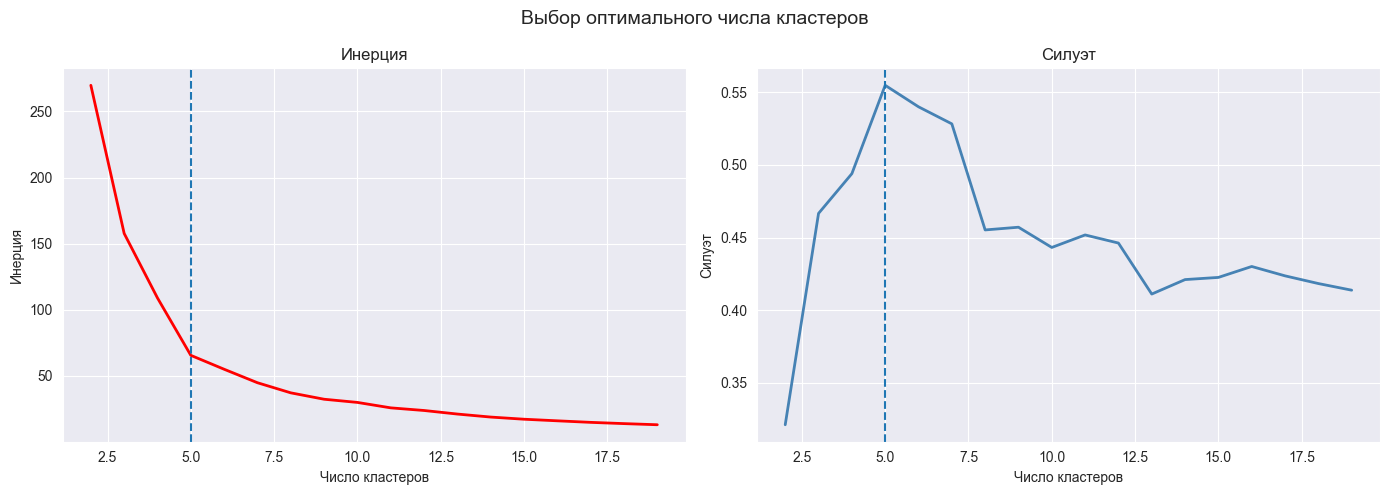

In [41]:
# ЗАДАНИЕ: визуализируйте изменение метрик при изменении k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Выбор оптимального числа кластеров', fontsize=14)

# inertia
ax = axes[0]
ax.plot(K_range, inertias, color='red', linewidth=2)
ax.set_title('Инерция')
ax.set_xlabel('Число кластеров')
ax.set_ylabel('Инерция')
ax.axvline(x=best_k, linestyle='--')

# silhouette_scores
ax = axes[1]
ax.plot(K_range, silhouette_scores, color='steelblue', linewidth=2)
ax.set_title('Силуэт')
ax.set_xlabel('Число кластеров')
ax.set_ylabel('Силуэт')
ax.axvline(x=best_k, linestyle='--')

plt.tight_layout()
plt.show()

In [42]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers['Cluster'] = kmeans_final.fit_predict(X)

KeyError: 'Gender_label'

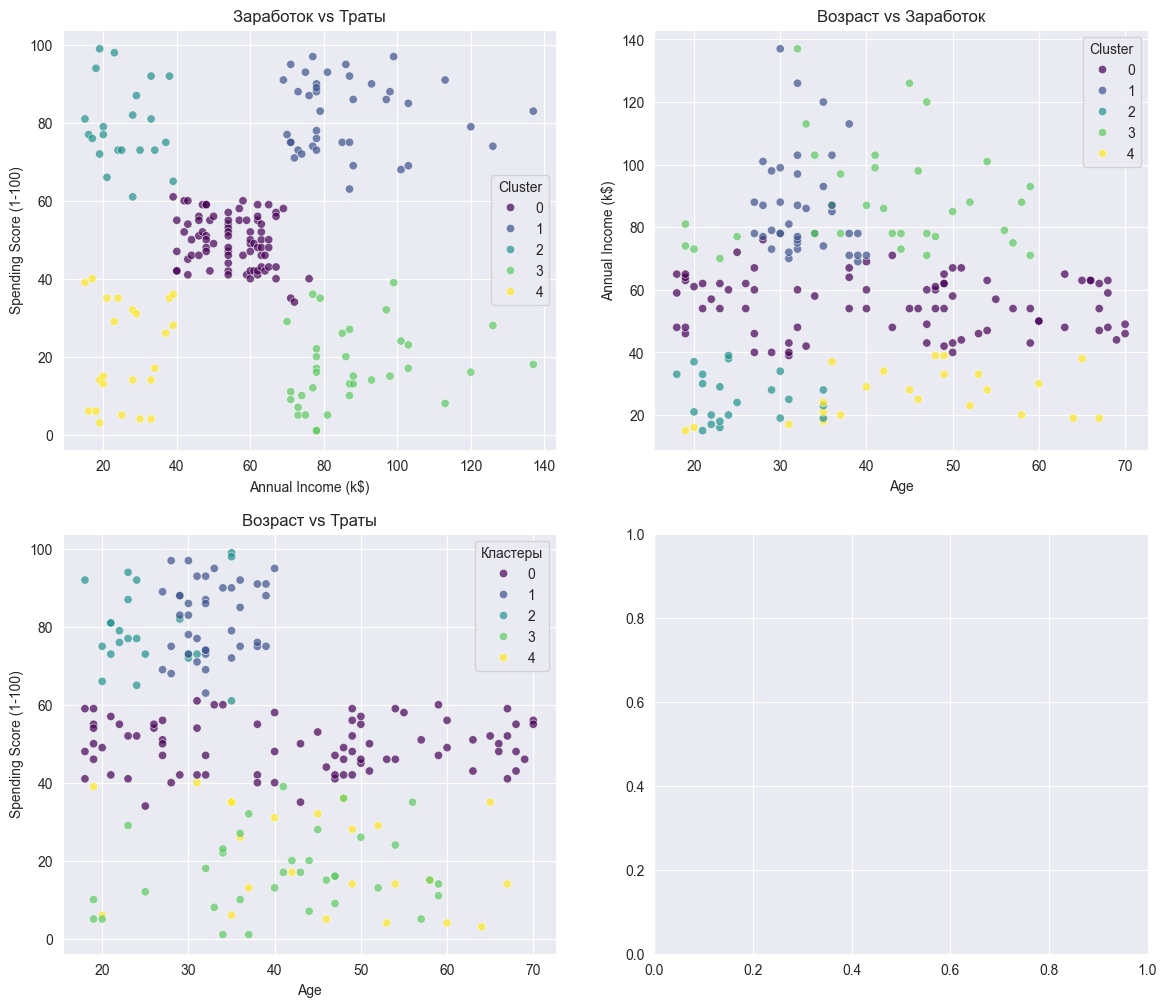

In [43]:
# ЗАДАНИЕ: визуализируйте кластеры
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Доход vs траты
sns.scatterplot(data=customers, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Заработок vs Траты')
axes[0, 0].legend(title='Cluster')

# Возраст vs доход
sns.scatterplot(data=customers, x='Age', y='Annual Income (k$)', hue='Cluster', palette='viridis', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Возраст vs Заработок')
axes[0, 1].legend(title='Cluster')


# Возраст vs траты
sns.scatterplot(data=customers, x='Age', y='Spending Score (1-100)', hue='Cluster', palette='viridis', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Возраст vs Траты')
axes[1, 0].legend(title='Кластеры')

# Столбчатая диаграмма
gender_counts = pd.crosstab(customers['Cluster'], customers['Gender_label'])
sns.histplot(data=customers, x = 'Gender', hue='Cluster', palette='viridis', multiple='dodge', ax=axes[1,1])

plt.tight_layout()
plt.show()

Повторите обучение для модели **без нормализации** признаков, есть ли разница?

In [ ]:
bad_inertias = []
bad_silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(bad_X)
    bad_inertias.append(kmeans.inertia_)
    bad_silhouette_scores.append(silhouette_score(bad_X, labels))

best_k = K_range[np.argmax(bad_silhouette_scores)]

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers['Cluster'] = kmeans_final.fit_predict(bad_X)

# ЗАДАНИЕ: визуализируйте кластеры
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Доход vs траты
sns.scatterplot(data=customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='viridis', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Income vs Spending Score')
axes[0, 0].legend(title='Cluster')

# Возраст vs доход
sns.scatterplot(data=customers, x='Age', y='Annual Income (k$)',
                hue='Cluster', palette='viridis', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Age vs Income')
axes[0, 1].legend(title='Cluster')


# Возраст vs траты
sns.scatterplot(data=customers, x='Age', y='Spending Score (1-100)',
                hue='Cluster', palette='viridis', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Age vs Spending Score')
axes[1, 0].legend(title='Cluster')

# Столбчатая диаграмма
gender_counts = pd.crosstab(customers['Cluster'], customers['Gender_label'])
gender_counts.plot(kind='bar', ax=axes[1, 1], color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axes[1, 1].set_title('Gender Distribution per Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Gender')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

**ВЫВОД**:

Я получил довольно странный результат: С StandartScaler я получаю целых 19 кластеров, с MinMaxScaler получаю всего два кластера, с без нормализации - 6 (как и должно быть, по идее). Я посмотрел, для этого датасета по идее и должно получаться 5-6 кластеров.  Кажется, что должно быть наоборот - с нормализацией должно быть лучше. Не понимаю, почему так: несколько раз перепроверял код, вроде, всё в порядке, ничего не перепутано. Нельзя ж сделать вывод, что лучше не нормализовывать... Кажется, я понимаю: нормализация делает так, что все данные вносят одинаковый вклад. Однако, необходимая структура кластеров видна только в плоскости Income x Spending Score, которые без нормализации доминируют по масштабу и сильнее влияют, чем остальные. А с нормализацией все признаки получают одинаковый вес. Получается, на конкретно этом датасете она усиливает признаки, которые не несут важной информации для кластеризации. Именно поэтому так происходит...

*Только когда я уже пост-фактум удалил все признаки, кроме income и score, я получил желаемый результат - 5 кластеров.*

## Вопросы (0,5 pt)

1. Можно ли составить портреты кластеров? Если да, то какой самый явный?
2. Влияет ли на кластеризацию способ обработки категориального признака?

**ОТВЕТЫ:**

1. Да, можно. В этом же и есть задача кластеризации: что толку в разделении данных, если мы не можем его интерпретировать. Я бы выделил следующие кластеры:

|  Номер | Доход | Уровень трат | Портрет | 
| :-| :------------ | :------------ | :--------| 
| 0 | от 40 до 60  | от 40 до 60 | Среднячки |
| 1 | от 70 до 100 (в среднем) | до 40 | Скряги: большой доход, но низкий уровень трат |
| 2 | до 40 | от 60  | Бедные, но транжиры: низкий доход, высокий уровень трат |
| 3 | от 40 до 60  | от 40 до 60 | Среднячки 2, эти кластеры отличаются возрастом (молодые и пожилые) |
| 4 | от 60 | от 70 | Богатые транжиры: кажется, именно это и есть целевая |
| 5 | до 40  | до 40 | Бедные и экономные |

2. В данном случае - почти не влияет. Gender и так бинарный, что OHE, что Ordinal дадут практически один и тот же результат. Только в одном случае (OHE) колонка будет одна, а в случае Ordinal - две. Тем не менее, как писал выше, для разделения по кластерам гендер значения не имеет, значит, способ обработки этого признака не должен влиять на результат

# Итоговый отчет (1 pt)

Напишите итоговый отчет о работе с данными и метриками в формате **советов себе**:
- зафиксируйте, что лучше использовать и как,
- что лучше не использовать и почему,
- какие фишки для упрощения работы вы себе советуете

Отчет должен иметь **структуру** и занимать **не менее 15 строк**.

#### Предобработка
- Масштабирование: Обязательно для линейных моделей и для кластеризации, но важно понимать, с какими данными ты работаешь и какие признаки отобраны, потому что результат может быть **очень** разным. Деревья не чувствительны к масштабу, можно не тратить на это время, это почти не улучшит результат.
- Отбор признаков: Для задач регрессии и классификации он важен, но не настолько, как для кластеризации. Кажется, для кластеризации сначала стоит построить графики, а уже потом грамотно отобрать только те признаки, которые действительно качественно различают группы.
- Разделять типы признаков - замечательно и даже обязательно. Гнать всё через один препроцессор попросту глупо. Задавать порядок для Ordinal нужно вручную (если данные текстовые), иначе будет алфавитным и бессмысленным для модели
- OHE лучше Ordinal для линейных моделей, если размерность позволяет. Target Encoder и вовсе прекрасен, всегда бы пробовал и его тоже, к тем признакам, которые кажутся сильно влияющими на target.

#### Пайплайны
- ColumnTransformer и Pipeline - мегаудобно, однозначно стоит применять, чтобы избежать ошибок.
- Разные циклы - лучше разные переменные. Я напоролся на это при работе с кластеризацией (думаю, в связи с некорректным порядком запуска ячеек и пр.), больше не хочу.

#### Модели
- RF лучше SGD на нелинейных задачах, что напрямую следует из их архитектуры. 
- Порог классификации - важный гиперпараметр (как и многие другие, конечно). GridSearch или RandomizedSearch - хорошая практика, не стоит упускать возможность лишний раз улучшить метрику.

#### Метрики
- Регрессия: Если используем MAE и RMSE, стоит смотреть на них вместе. Об этом сказано было ещё в теории, хочется это зафиксировать. Если RMSE >> MAE, стоит задуматься. R2 - не всегда хорошая метрика на мой взгляд, бывает тяжело интепретировать, MAPE мне показалась наиболее информативной и корректной одновременно.
- Классификация: Accuracy при дисбалансе не доверяем. Я бы смотрел на precision + recall + f1 вместе: всё зависит от задачи, иногда precision и recall неравноценны и нужно делать упор на что-то одно. Очень важно помнить про порог, решая классификацию
- Кластеризация: Главная фиксация - для кластеризации нет правильного ответа, и в этом вся проблема. Метрика лишь подсказывает. Итоговый критерий - именно интерпретируемость кластеров. Силуэт - не всегда корректная по смыслу метрика: максимум при k=19 был корректен, но его невозможно было интерпретировать, а значит, задача не решена и результат бессмысленен. Она отвечает за компактность кластеров, но не за интерпретируемость.